# Client Check In

A common problem that banks face, specifically private concierge banks, is keeping up with their clients' lives. A nonprofit might lose its executive director. A poker player might have a big tournament win or a major loss. A business owner might be getting acquired.

These are moments where the bank could step in and offer real help, whether it be adjusting a loan, suggesting a new product, or scheduling a planning meeting. But too often, they find out too late or not at all.

The result is that follow-up slacks, the data they have is not actionable, the service they provide is not at its best, and the personal relationship between the client and the bank starts to suffer.
The solution is a client check-in system where clients periodically share life and business updates through a simple Google Form. The bank's team gets an AI-powered dashboard that reads those responses, flags anything significant, and tells the banker exactly who to reach out to and why.

This removes the manual labor of tracking dozens of client relationships at once, while keeping the human relationship intact. The banker still makes the call. The AI just makes sure nobody falls through the cracks.

To complete the system, a Make.com automation alerts bankers the moment a new response comes in, so they can reach out to the client as soon as possible.

The workflow looks like this:

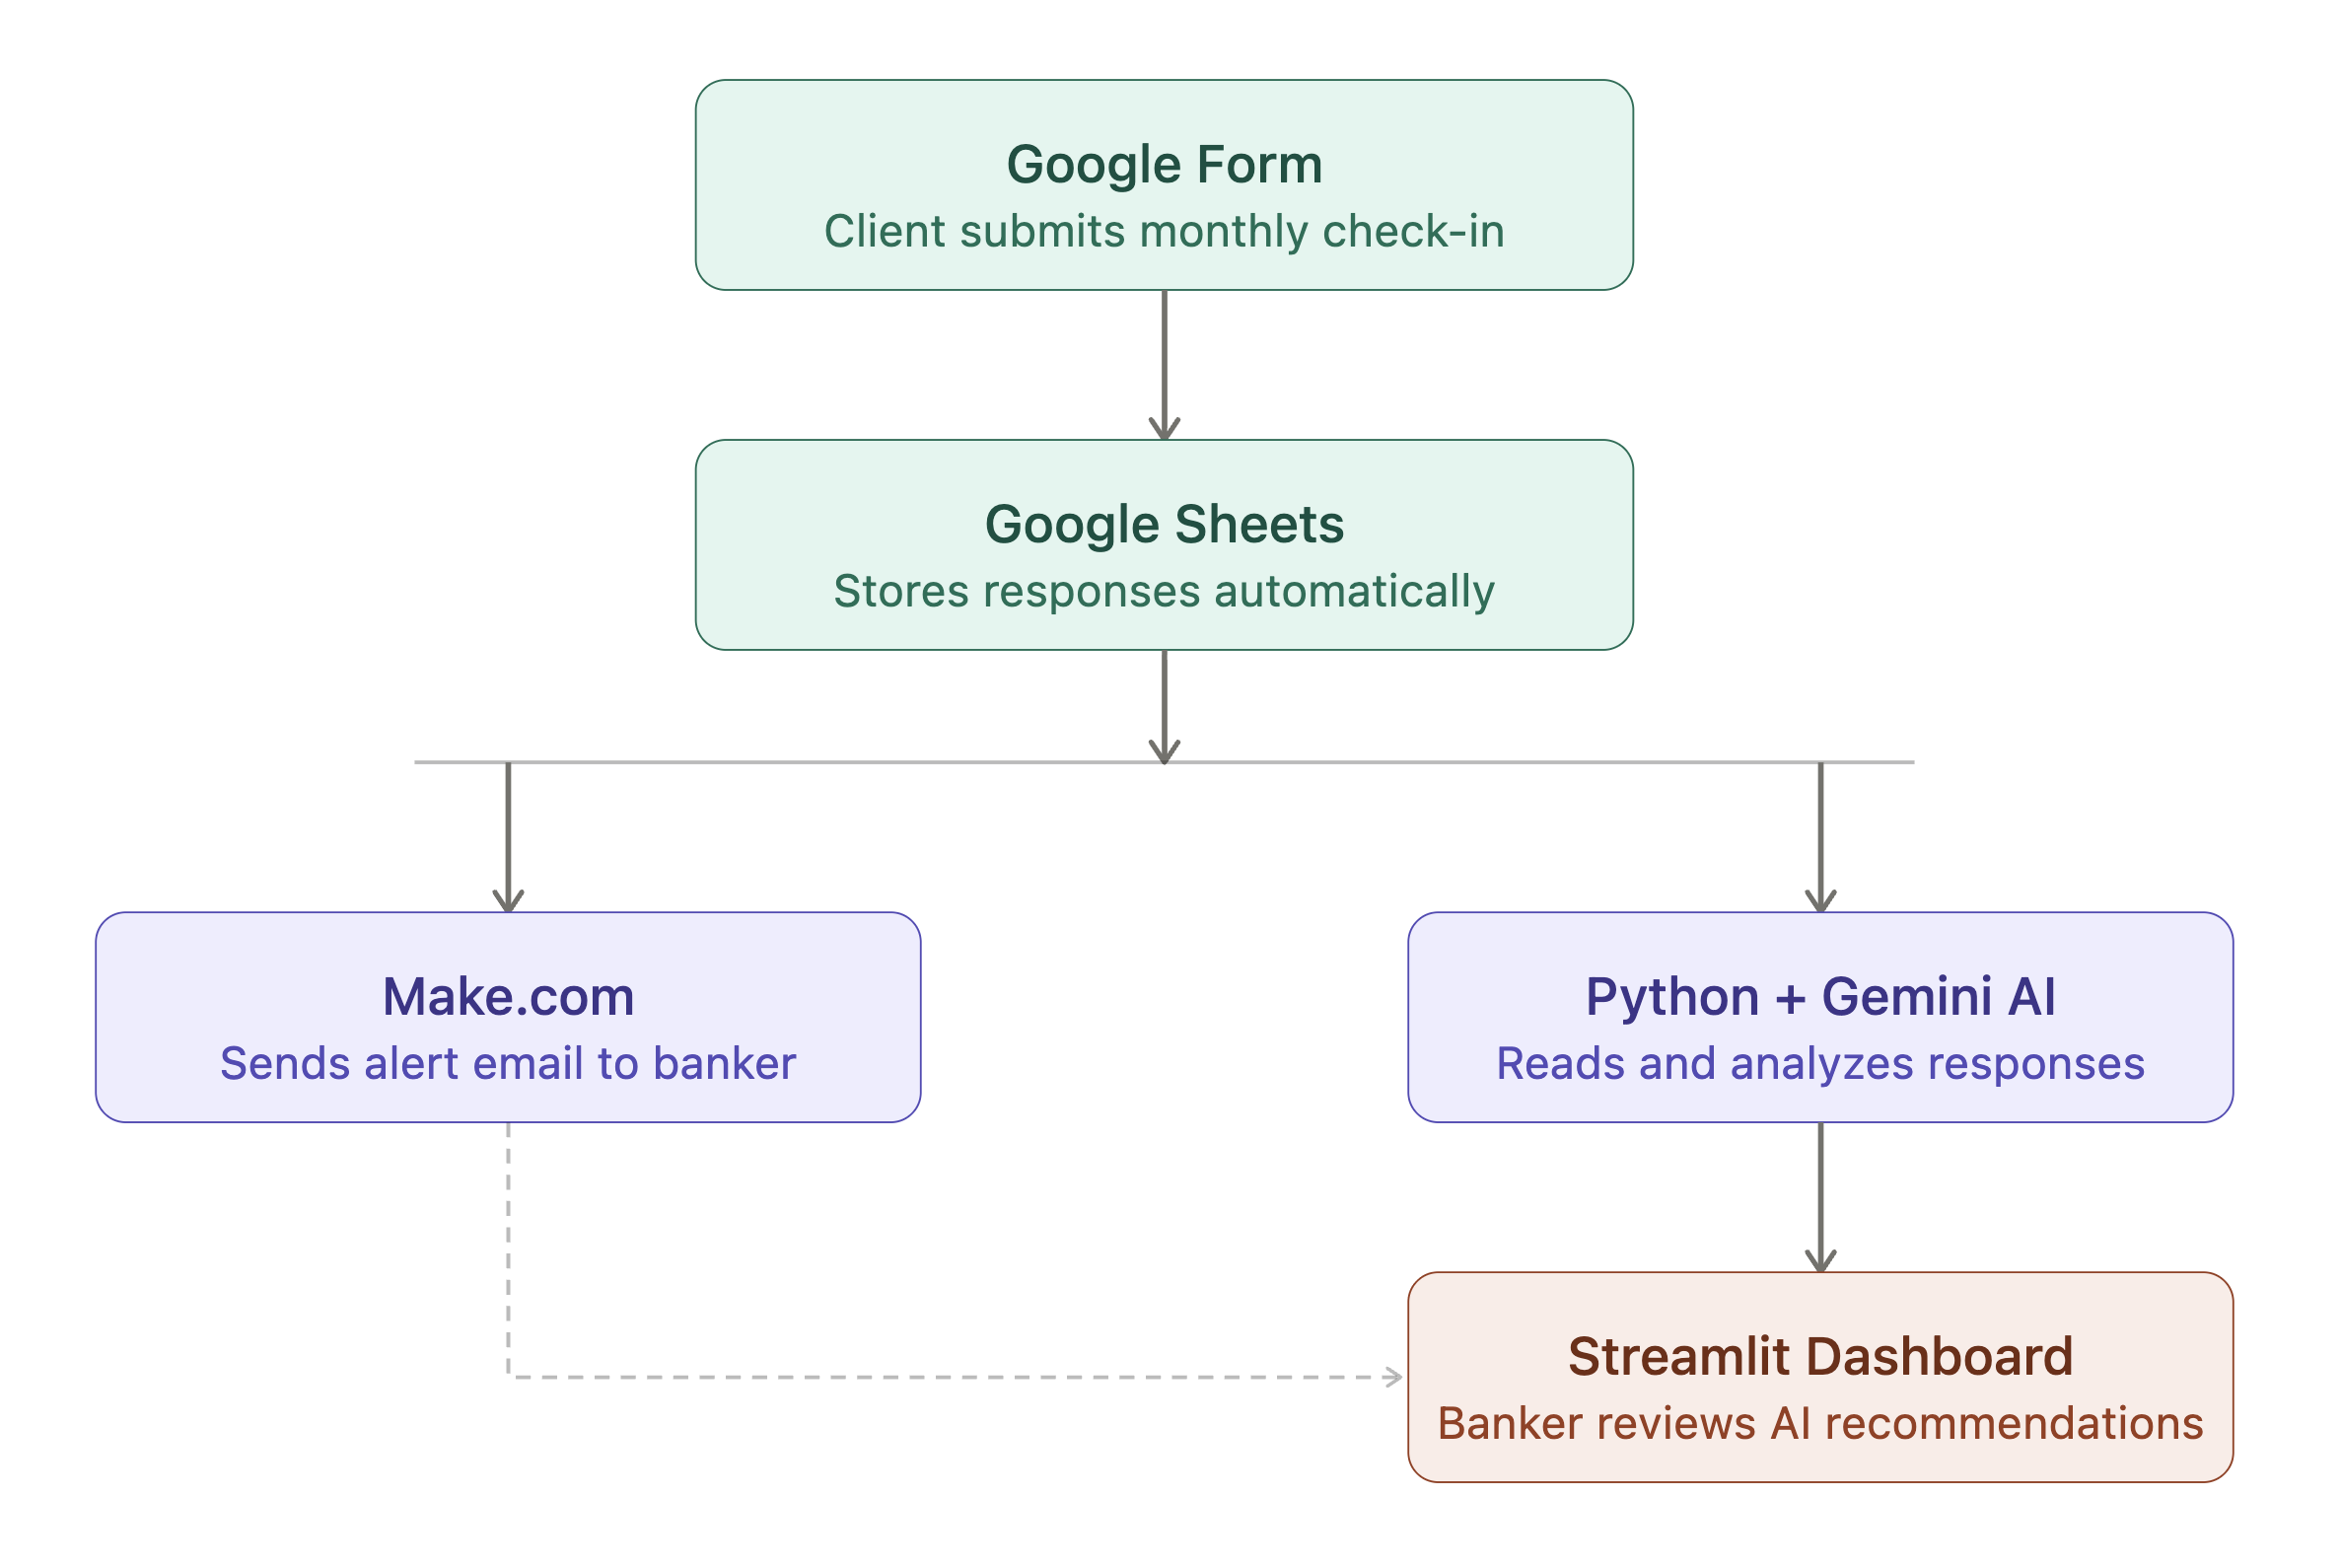

The notification side of the system is handled by Make.com, a no-code automation tool. The scenario watches for new rows in the Google Sheet every 15 minutes. When a new client response is detected, it automatically sends an email alert to the banker with the client's name and a link to the dashboard. This ensures bankers are notified in near real time without having to manually check the sheet:

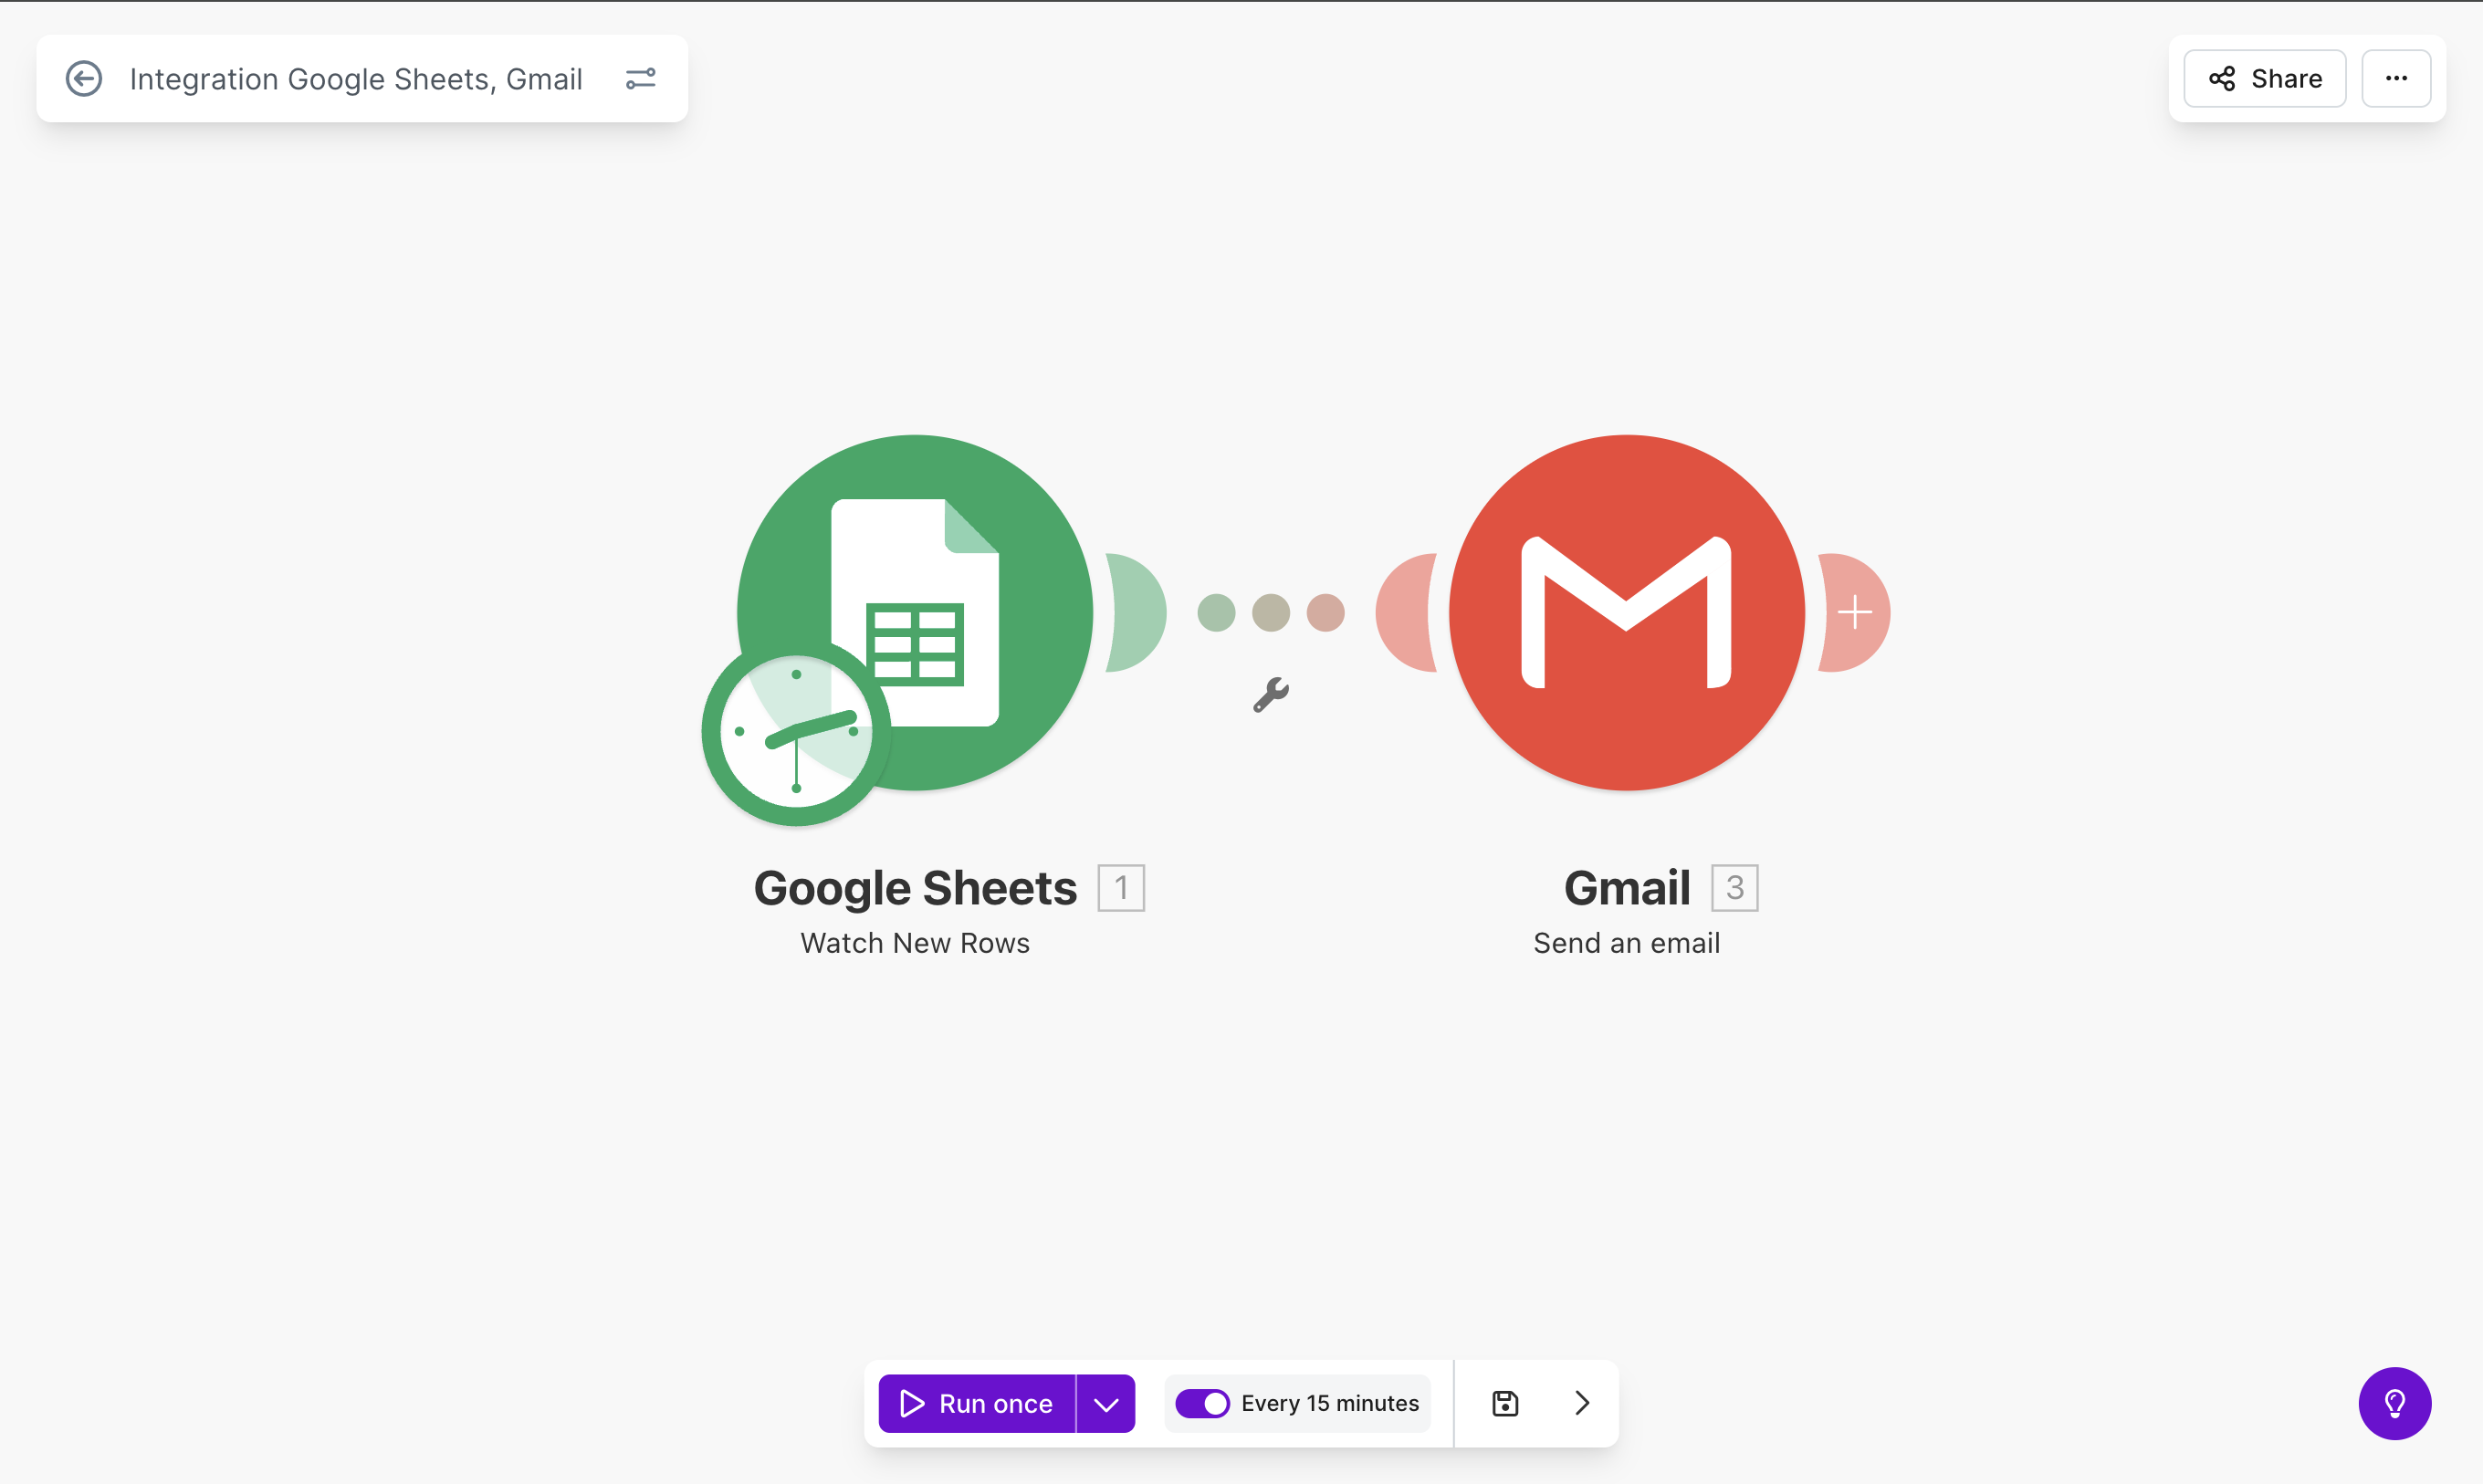

In this notebook, we will walk through the full pipeline. This includes an overview of the Google Form used to collect client responses, how those responses flow automatically into Google Sheets, the Make.com automation that alerts bankers in real time, and the Python code that reads the sheet, uses Gemini AI to analyze each response, and powers the Streamlit dashboard.

This notebook will focus on the Python portion of the pipeline, where it processes responses from the Google Sheet, uses Gemini AI to analyze each one, and builds the Streamlit dashboard.
Let's start with reading and processing the responses from the Google Sheet.

## Importing Libraries

This project uses the following libraries:

**os:** accesses environment variables and files from the operating system, used here to securely load our API key

**pandas:** reads and manipulates the response data from Google Sheets into a structured dataframe

**gspread:** connects Python to Google Sheets so we can pull responses directly without downloading a file manually

**google.oauth2.service_account:** handles authentication with Google's API using our service account credentials

**google.genai:** integrates Gemini AI so we can send client responses and receive structured analysis back

**dotenx:** loads environment variables from a local .env file so sensitive credentials like API keys are never hardcoded directly in the notebook.

In [1]:
import os
import pandas as pd
import gspread as gs
from google.oauth2.service_account import Credentials
from google import genai
from dotenv import load_dotenv

Now that we have or libraries, we will read our data from the the Google Sheet. 

## Reading the Google Sheet

First, we define the scope, which tells Google what this Python script is allowed to access. In this case, we are giving it permission to read from Google Sheets and access Google Drive, which is where the sheet lives.

Next, we load our credentials from a local JSON file. This file acts as an ID card that proves to Google that this script is authorized to access our private spreadsheet. Without it, Google would reject the request.

We then authorize the credentials using **gspread**, which creates an authenticated client that can communicate with Google's API.

Finally, we open the spreadsheet by name, pull all the responses into a Python list, and convert it into a Pandas dataframe so we can work with the data easily.

In [2]:
# define the scope
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]

# credentials from JSON file
creds = Credentials.from_service_account_file("credentials.json", scopes=scope)

# authorize
client = gs.authorize(creds)

# open spreadsheet
sheet = client.open("Client Monthly Check-In (Responses)").sheet1

# pull all data to a dataframe
data = sheet.get_all_records()
df = pd.DataFrame(data)

# preview data
df.head()

,Timestamp,First Name,Last Name,"What is your phone number? (short answer)\nExample: 7021234567 — please enter numbers only, no dashes or spaces",Which of the following best describes your past month?,Please describe your update or situation in your own words.,Would you like a team member to reach out to discuss this?,What is the best way to reach you to schedule a time to connect?,Email Address
0,2026-03-01 09:14:00,Marcus,Delgado,7025550101,"A major business change occurred (acquisition,...",My restaurant group just signed a lease for a ...,"Yes, I'd love to connect",Phone call,marcus.delgado@email.com
1,2026-03-02 11:32:00,Yolanda,Tran,7025550102,A major financial change occurred (significant...,Won big.,"Yes, I'd love to connect",Email,yolanda.tran@email.com
2,2026-03-03 14:05:00,DeShawn,Okafor,7025550103,"Nothing major has happened, but I have a gener...",Season is going well. Just checking in. My con...,"Yes, I'd love to connect",Phone call,deshawn.okafor@email.com
3,2026-03-04 10:20:00,Sofia,Mendez,7025550104,"A legal matter came up (lawsuit, arrest, settl...",Our nonprofit is being audited by the IRS. We ...,"Yes, I'd love to connect",In-person meeting,sofia.mendez@helpinghands.org
4,2026-03-05 08:45:00,Raymond,Kwon,7025550105,"A major business change occurred (acquisition,...",Lost our executive director.,"Yes, I'd love to connect",Phone call,raymond.kwon@desertnpo.org


Now that we are able to pull data from our spreadsheet, we will configure Gemini AI and clean up our dataframe before analysis.

## Configure Gemini AI

We load our Gemini API key from the .env file using load_dotenv(). This keeps our credentials secure and out of the notebook so they are never accidentally exposed when sharing or uploading the project.

In [3]:
# load API key
load_dotenv()
gemini_client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

## Cleaning the Dataframe

When Google Forms pipes responses into Google Sheets, the column headers are the full question text, which is long and messy to work with in Python. We rename them to short, meaningful column names. We also combine the first and last name columns into a single client name column for cleaner output.

In [4]:
# map spreasheet columns as simpler column names
df.columns = ['Timestamp', 'First Name', 'Last Name', 'Phone', 'Situation Type', 'Details', 'Connect', 'Contact', 'Email']

# set client name as first and last name
df['Client Name'] = df['First Name'] + ' ' + df['Last Name']

## Analyzing Responses with Gemini AI

This section is the core of the pipeline. We filter the dataframe to only include rows where the client actually provided details, send each response to Gemini AI with a structured prompt, parse the output into clean columns, and store everything in a final dataframe ready for the dashboard.

### Filtering and Parsing

First, we filter out any rows where the client did not provide a written description, since there is nothing to analyze. We also define a parser function that reads Gemini's response and extracts the four key fields we asked for: Summary, Urgency, Category, and Recommended Action. We define this function before the loop so it is ready to use when we need it.

In [5]:
# only analyze rows where client provided details
df_with_details = df[df['Details'].str.strip() != ''].copy()

# parse Gemini's structured response into individual fields
def parse_analysis(text):
    lines = text.strip().split('\n')
    parsed = {}
    for line in lines:
        if line.startswith('SUMMARY:'):
            parsed['Summary'] = line.replace('SUMMARY:', '').strip()
        elif line.startswith('URGENCY:'):
            parsed['Urgency'] = line.replace('URGENCY:', '').strip()
        elif line.startswith('CATEGORY:'):
            parsed['Category'] = line.replace('CATEGORY:', '').strip()
        elif line.startswith('ACTION:'):
            parsed['Action'] = line.replace('ACTION:', '').strip()
    return parsed

### Prompting Gemini and Building the Final Dataframe

We loop through each client response and send it to Gemini with a carefully structured prompt. The prompt tells Gemini exactly who it is, what the context is, and how to format its response. By specifying the exact format we want, we make it easy to parse the output programmatically. Each result is stored in a list and converted into a final dataframe.

In [6]:
# empty list to store each analyzed row
parsed_rows = []

# loop through each client response that has details
for index, row in df_with_details.iterrows():

    # extract relevant fields from the row
    client_name = row['Client Name']
    situation = row['Situation Type']
    details = row['Details']

    # build the prompt with client context and strict formatting instructions
    prompt = f"""You are an assistant helping relationship managers at a concierge community bank.

A client named {client_name} submitted the following monthly check-in update:
Situation type they selected: {situation}
Their description: "{details}"

Please respond in exactly this format with no extra text:
SUMMARY: [one sentence summary]
URGENCY: [Low, Medium, or High]
CATEGORY: [Legal, Business Change, Major Purchase, Personal Life Event, Financial Change, or General Update]
ACTION: [recommended action for the banker]"""

    # send the prompt to Gemini and get a response
    response = gemini_client.models.generate_content(
        model="gemini-3.1-flash-lite-preview",
        contents=prompt
    )

    # parse Gemini's response into structured fields
    parsed = parse_analysis(response.text)

    # append the full row with AI analysis to the results list
    parsed_rows.append({
        'Name': client_name,
        'Phone': row['Phone'],
        'Email': row['Email'],
        'Situation Type': situation,
        'Details': details,
        'Connect': row['Connect'],
        'Contact': row['Contact'],
        'Summary': parsed.get('Summary', ''),
        'Urgency': parsed.get('Urgency', ''),
        'Category': parsed.get('Category', ''),
        'Recommended Action': parsed.get('Action', '')
    })

# convert results list into a final dataframe
df_final = pd.DataFrame(parsed_rows)
df_final

,Name,Phone,Email,Situation Type,Details,Connect,Contact,Summary,Urgency,Category,Recommended Action
0,Marcus Delgado,7025550101,marcus.delgado@email.com,"A major business change occurred (acquisition,...",My restaurant group just signed a lease for a ...,"Yes, I'd love to connect",Phone call,"Marcus Delgado is seeking $600,000 in financin...",High,Business Change,Schedule a discovery call within 24 hours to d...
1,Yolanda Tran,7025550102,yolanda.tran@email.com,A major financial change occurred (significant...,Won big.,"Yes, I'd love to connect",Email,Client Yolanda Tran reported a significant fin...,High,Financial Change,Contact the client immediately to congratulate...
2,DeShawn Okafor,7025550103,deshawn.okafor@email.com,"Nothing major has happened, but I have a gener...",Season is going well. Just checking in. My con...,"Yes, I'd love to connect",Phone call,DeShawn Okafor indicated that his contract sta...,Medium,Business Change,Reach out to DeShawn to schedule a consultativ...
3,Sofia Mendez,7025550104,sofia.mendez@helpinghands.org,"A legal matter came up (lawsuit, arrest, settl...",Our nonprofit is being audited by the IRS. We ...,"Yes, I'd love to connect",In-person meeting,Sofia Mendez reported that her nonprofit is un...,High,Legal,Schedule a meeting to review current account s...
4,Raymond Kwon,7025550105,raymond.kwon@desertnpo.org,"A major business change occurred (acquisition,...",Lost our executive director.,"Yes, I'd love to connect",Phone call,Raymond Kwon reported the departure of his com...,High,Business Change,Reach out immediately to offer support and ass...
5,Aaliyah Washington,7025550106,aaliyah.washington@email.com,I made or am planning a major purchase or inve...,I am closing on a home in Henderson next month...,"Yes, I'd love to connect",Email,Aaliyah Washington is a first-time homebuyer c...,High,Major Purchase,Schedule a call with Aaliyah to review her cur...
6,Carlos Reyes,7025550107,carlos.reyes@email.com,A significant personal life event happened (ma...,My father passed away last month and I am now ...,"Yes, I'd love to connect",In-person meeting,Carlos Reyes is navigating the estate of his l...,High,Personal Life Event,Schedule a priority meeting with the client to...
7,Priya Nair,7025550108,priya.nair@vegascares.org,"Nothing major has happened, but I have a gener...",Things are steady. Grant funding came through ...,"No, I just wanted to keep you informed",,Priya Nair confirmed that Q2 grant funding has...,Low,General Update,Send a brief note congratulating Priya on the ...
8,Jalen Brooks,7025550109,jalen.brooks@email.com,A major financial change occurred (significant...,I had a rough stretch at the tables this month...,"Yes, I'd love to connect",Phone call,"Jalen Brooks experienced a $90,000 loss from g...",High,Financial Change,Schedule a priority meeting to conduct a liqui...


## Launching the Streamlit Dashboard

The final step is launching the Streamlit dashboard, which serves as the banker-facing interface for this system. Streamlit runs as a separate web application and cannot be launched directly inside Jupyter, so we use Python's subprocess module to run it from within the notebook. Once launched, the dashboard is accessible at http://localhost:8515 in your browser.

In [8]:
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])

<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8515
  Network URL: http://192.168.0.16:8515



2026-03-22 20:42:04.633 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-22 20:42:40.255 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


## Conclusion

This notebook walked through the full Python pipeline for the Client Check-In System, from reading responses out of Google Sheets, to analyzing them with Gemini AI, to launching the Streamlit dashboard. Combined with the Google Form for client input and the Make.com automation for banker notifications, this system provides a complete end-to-end solution for concierge banks to stay informed about their clients' lives and act before it's too late.

The amount of detail a client provides will naturally vary. Some clients will share a lot, others very little. Regardless, the AI layer is designed to read whatever is submitted and guide the banker on what the next step should be, making every response actionable no matter how brief or detailed.

There are a few areas I would like to improve on in future iterations. First, when a banker receives a notification email, it currently links to the main Streamlit dashboard rather than directly to that specific client's record. Ideally the link would take the banker straight to the relevant client detail view. Second, the current system displays a new row every time a client submits a check-in, meaning a client who submits multiple times appears more than once in the dashboard. A better approach would be to group all check-ins by client so each person appears once, with a history of their previous submissions attached to their profile. This would keep the data clean and make the dashboard easier to navigate over time.

That said, this project directly addresses the core problem: concierge banks losing track of their clients and missing the moments that matter most. The system built here is a working prototype that solves that problem end to end.